In [31]:
import os
import time
import pandas as pd
import duckdb
import ocha_stratus as stratus
from dotenv import load_dotenv

load_dotenv()

TABLE = "imerg"
STAGE = "dev"
SAS = os.getenv("DSCI_AZ_BLOB_DEV_SAS")
ACCOUNT_NAME = "imb0chd0dev"

timings = {}

In [32]:
iso3 = "AFG"

sql_query = f"""
    SELECT * FROM {TABLE}
    WHERE iso3 = '{iso3}'
    AND pcode = 'AF01'
    ORDER BY valid_date
"""

## 1. Read benchmarking from partitioned Parquet files

In [33]:
# 1. Setup connection
conn_az = duckdb.connect()
conn_az.execute("INSTALL azure; LOAD azure;")
conn_az.execute(f"""
    CREATE SECRET azure_secret (
        TYPE AZURE,
        PROVIDER config,
        CONNECTION_STRING 'AccountName={ACCOUNT_NAME};SharedAccessSignature={SAS}'
    )
""")

### 1.1 Read from files partitioned by year and iso3

In [34]:
conn_az.execute(f"""
    CREATE OR REPLACE VIEW {TABLE} AS
    SELECT * FROM read_parquet(
        'az://rasterstats-public-l2/{TABLE}/iso3={iso3}/*.parquet',
        hive_partitioning = true
    )
""")

t0 = time.perf_counter()
df_az_l2 = conn_az.execute(sql_query).df()
timings["l2 (iso3 + year)"] = time.perf_counter() - t0

print(df_az_l2.head())
print(f"Rows: {len(df_az_l2):,} | Time: {timings['l2 (iso3 + year)']:.2f}s")

  iso3 pcode valid_date  adm_level      mean  median    min   max  count  \
0  AFG  AF01 1998-01-01          1  0.029385   0.000  0.000  0.40    179   
1  AFG  AF01 1998-01-02          1  0.966257   0.740  0.185  4.95    179   
2  AFG  AF01 1998-01-03          1  1.110782   0.495  0.020  6.22    179   
3  AFG  AF01 1998-01-04          1  0.290223   0.090  0.000  1.80    179   
4  AFG  AF01 1998-01-05          1  0.006341   0.000  0.000  0.76    179   

          sum       std  
0    5.260000  0.100788  
1  172.959990  0.838163  
2  198.830000  1.404849  
3   51.949997  0.428177  
4    1.135000  0.059583  
Rows: 10,333 | Time: 8.75s


## 1.2 Read from files partitioned by iso3

In [35]:
conn_az.execute(f"""
    CREATE OR REPLACE VIEW {TABLE} AS
    SELECT * FROM read_parquet(
        'az://rasterstats-public-l1/{TABLE}/iso3={iso3}/*.parquet',
        hive_partitioning = true
    )
""")

t0 = time.perf_counter()
df_az_l1 = conn_az.execute(sql_query).df()
timings["l1 (iso3 only)"] = time.perf_counter() - t0

print(df_az_l1.head())
print(f"Rows: {len(df_az_l1):,} | Time: {timings['l1 (iso3 only)']:.2f}s")

  iso3 pcode valid_date  adm_level      mean  median    min   max  count  \
0  AFG  AF01 1998-01-01          1  0.029385   0.000  0.000  0.40    179   
1  AFG  AF01 1998-01-02          1  0.966257   0.740  0.185  4.95    179   
2  AFG  AF01 1998-01-03          1  1.110782   0.495  0.020  6.22    179   
3  AFG  AF01 1998-01-04          1  0.290223   0.090  0.000  1.80    179   
4  AFG  AF01 1998-01-05          1  0.006341   0.000  0.000  0.76    179   

          sum       std  
0    5.260000  0.100788  
1  172.959990  0.838163  
2  198.830000  1.404849  
3   51.949997  0.428177  
4    1.135000  0.059583  
Rows: 10,333 | Time: 5.87s


## 2. From PostgreSQL database

In [36]:
engine = stratus.get_engine("prod")

t0 = time.perf_counter()
with engine.connect() as conn_db:
    df_db = pd.read_sql(sql_query, conn_db)
timings["postgresql"] = time.perf_counter() - t0

print(df_db.head())
print(f"Rows: {len(df_db):,} | Time: {timings['postgresql']:.2f}s")

  iso3 pcode  valid_date  adm_level      mean  median    min   max  count  \
0  AFG  AF01  1998-01-01          1  0.029385   0.000  0.000  0.40    179   
1  AFG  AF01  1998-01-02          1  0.966257   0.740  0.185  4.95    179   
2  AFG  AF01  1998-01-03          1  1.110782   0.495  0.020  6.22    179   
3  AFG  AF01  1998-01-04          1  0.290223   0.090  0.000  1.80    179   
4  AFG  AF01  1998-01-05          1  0.006341   0.000  0.000  0.76    179   

          sum       std  
0    5.260000  0.100788  
1  172.959990  0.838163  
2  198.830000  1.404849  
3   51.949997  0.428177  
4    1.135000  0.059583  
Rows: 10,333 | Time: 19.98s


In [37]:
print(f"{'Storage':<20} {'Time (s)':>10}")
print("-" * 31)
fastest = min(timings.values())
for label, t in timings.items():
    print(f"{label:<20} {t:>9.2f}s  {'(baseline)' if t == fastest else f'({t/fastest:.1f}x slower)'}")

Storage                Time (s)
-------------------------------
l2 (iso3 + year)          8.75s  (1.5x slower)
l1 (iso3 only)            5.87s  (baseline)
postgresql               19.98s  (3.4x slower)


## 3. Benchmark — repeated runs

In [38]:
import numpy as np
import matplotlib.pyplot as plt

N = 5

def make_conn():
    conn = duckdb.connect()
    conn.execute("INSTALL azure; LOAD azure;")
    conn.execute(f"""
        CREATE SECRET azure_secret (
            TYPE AZURE,
            PROVIDER config,
            CONNECTION_STRING 'AccountName={ACCOUNT_NAME};SharedAccessSignature={SAS}'
        )
    """)
    return conn

def bench_l2():
    conn = make_conn()
    conn.execute(f"""
        CREATE OR REPLACE VIEW {TABLE} AS
        SELECT * FROM read_parquet(
            'az://rasterstats-public-l2/{TABLE}/iso3={iso3}/*.parquet',
            hive_partitioning = true
        )
    """)
    return conn.execute(sql_query).df()

def bench_l1():
    conn = make_conn()
    conn.execute(f"""
        CREATE OR REPLACE VIEW {TABLE} AS
        SELECT * FROM read_parquet(
            'az://rasterstats-public-l1/{TABLE}/iso3={iso3}/*.parquet',
            hive_partitioning = true
        )
    """)
    return conn.execute(sql_query).df()

def bench_db():
    with engine.connect() as conn_db:
        return pd.read_sql(sql_query, conn_db)

benchmarks = {
    "l2 (iso3 + year)": bench_l2,
    "l1 (iso3 only)":   bench_l1,
    "postgresql":        bench_db,
}

results = {}
for label, fn in benchmarks.items():
    times = []
    for i in range(N):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
        print(f"  {label} run {i+1}/{N}: {times[-1]:.2f}s")
    results[label] = times
    print(f"  → mean: {np.mean(times):.2f}s  std: {np.std(times):.2f}s\n")

  l2 (iso3 + year) run 1/5: 8.65s
  l2 (iso3 + year) run 2/5: 8.12s
  l2 (iso3 + year) run 3/5: 7.83s
  l2 (iso3 + year) run 4/5: 8.24s
  l2 (iso3 + year) run 5/5: 7.88s
  → mean: 8.14s  std: 0.29s

  l1 (iso3 only) run 1/5: 5.87s
  l1 (iso3 only) run 2/5: 5.81s
  l1 (iso3 only) run 3/5: 5.84s
  l1 (iso3 only) run 4/5: 5.00s
  l1 (iso3 only) run 5/5: 6.17s
  → mean: 5.74s  std: 0.39s

  postgresql run 1/5: 17.37s
  postgresql run 2/5: 16.90s
  postgresql run 3/5: 17.18s
  postgresql run 4/5: 16.97s
  postgresql run 5/5: 16.82s
  → mean: 17.05s  std: 0.20s



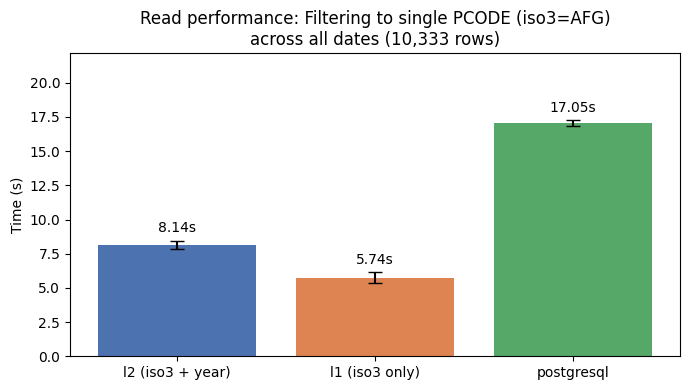

In [39]:
means = [np.mean(results[k]) for k in results]
stds  = [np.std(results[k])  for k in results]
labels = list(results.keys())

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, means, yerr=stds, capsize=5, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Time (s)")
ax.set_title(f"Read performance: Filtering to single PCODE (iso3={iso3})\nacross all dates ({len(df_db):,} rows)")
ax.bar_label(bars, fmt="%.2fs", padding=4)
ax.set_ylim(0, max(means) * 1.3)
plt.tight_layout()
plt.show()